In [1]:
import os
import urllib.request
import tarfile
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torchvision.utils import save_image
from torch.utils.data import Dataset, DataLoader
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

############################################
# CREATE RESULT FOLDER
############################################

os.makedirs("/content/results", exist_ok=True)

############################################
# DOWNLOAD DATASET
############################################

url = "http://efrosgans.eecs.berkeley.edu/pix2pix/datasets/edges2shoes.tar.gz"

if not os.path.exists("/content/edges2shoes"):

    print("Downloading dataset...")

    urllib.request.urlretrieve(url, "/content/edges2shoes.tar.gz")

    print("Extracting dataset...")

    with tarfile.open("/content/edges2shoes.tar.gz") as tar:
        tar.extractall(path="/content", filter="data")

############################################
# DATASET
############################################

class Pix2PixDataset(Dataset):

    def __init__(self, root_dir):

        self.root = root_dir

        # USE SMALL SUBSET FOR FAST TRAINING
        self.files = os.listdir(root_dir)[:2000]

        self.transform = transforms.Compose([
            transforms.Resize((256,256)),
            transforms.ToTensor(),
            transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
        ])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):

        img = Image.open(os.path.join(self.root,self.files[idx])).convert("RGB")

        w,h = img.size

        input_img = img.crop((0,0,w//2,h))
        target_img = img.crop((w//2,0,w,h))

        return self.transform(input_img), self.transform(target_img)

############################################
# U-NET GENERATOR
############################################

class UNetDown(nn.Module):

    def __init__(self,in_size,out_size,normalize=True):
        super().__init__()

        layers=[nn.Conv2d(in_size,out_size,4,2,1,bias=False)]

        if normalize:
            layers.append(nn.BatchNorm2d(out_size))

        layers.append(nn.LeakyReLU(0.2))

        self.model=nn.Sequential(*layers)

    def forward(self,x):
        return self.model(x)


class UNetUp(nn.Module):

    def __init__(self,in_size,out_size):
        super().__init__()

        self.model=nn.Sequential(
            nn.ConvTranspose2d(in_size,out_size,4,2,1,bias=False),
            nn.BatchNorm2d(out_size),
            nn.ReLU(True)
        )

    def forward(self,x,skip):

        x=self.model(x)

        x=torch.cat((x,skip),1)

        return x


class GeneratorUNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.down1=UNetDown(3,64,normalize=False)
        self.down2=UNetDown(64,128)
        self.down3=UNetDown(128,256)
        self.down4=UNetDown(256,512)

        self.up1=UNetUp(512,256)
        self.up2=UNetUp(512,128)
        self.up3=UNetUp(256,64)

        self.final=nn.Sequential(
            nn.ConvTranspose2d(128,3,4,2,1),
            nn.Tanh()
        )

    def forward(self,x):

        d1=self.down1(x)
        d2=self.down2(d1)
        d3=self.down3(d2)
        d4=self.down4(d3)

        u1=self.up1(d4,d3)
        u2=self.up2(u1,d2)
        u3=self.up3(u2,d1)

        return self.final(u3)

############################################
# PATCHGAN DISCRIMINATOR
############################################

class Discriminator(nn.Module):

    def __init__(self):
        super().__init__()

        def block(in_c,out_c,normalize=True):

            layers=[nn.Conv2d(in_c,out_c,4,2,1)]

            if normalize:
                layers.append(nn.BatchNorm2d(out_c))

            layers.append(nn.LeakyReLU(0.2))

            return layers

        self.model=nn.Sequential(

            *block(6,64,normalize=False),
            *block(64,128),
            *block(128,256),
            *block(256,512),

            nn.Conv2d(512,1,4,1,1)
        )

    def forward(self,img_A,img_B):

        x=torch.cat((img_A,img_B),1)

        return self.model(x)

############################################
# BASELINE CNN
############################################

class EncoderDecoder(nn.Module):

    def __init__(self):
        super().__init__()

        self.encoder=nn.Sequential(
            nn.Conv2d(3,64,4,2,1),
            nn.ReLU(),

            nn.Conv2d(64,128,4,2,1),
            nn.ReLU()
        )

        self.decoder=nn.Sequential(
            nn.ConvTranspose2d(128,64,4,2,1),
            nn.ReLU(),

            nn.ConvTranspose2d(64,3,4,2,1),
            nn.Tanh()
        )

    def forward(self,x):

        x=self.encoder(x)
        x=self.decoder(x)

        return x

############################################
# DATA LOADER
############################################

train_path="/content/edges2shoes/train"

dataset=Pix2PixDataset(train_path)

dataloader=DataLoader(dataset,batch_size=16,shuffle=True)

############################################
# MODELS
############################################

generator=GeneratorUNet().to(device)
discriminator=Discriminator().to(device)
cnn_model=EncoderDecoder().to(device)

############################################
# LOSSES
############################################

adversarial_loss=nn.BCEWithLogitsLoss()
l1_loss=nn.L1Loss()

############################################
# OPTIMIZERS
############################################

optimizer_G=optim.Adam(generator.parameters(),lr=0.0002,betas=(0.5,0.999))
optimizer_D=optim.Adam(discriminator.parameters(),lr=0.0002,betas=(0.5,0.999))
optimizer_CNN=optim.Adam(cnn_model.parameters(),lr=0.0002)

############################################
# TRAINING
############################################

epochs=3

for epoch in range(epochs):

    for i,(input_img,target_img) in enumerate(dataloader):

        input_img=input_img.to(device)
        target_img=target_img.to(device)

        #################################
        # GENERATOR
        #################################

        optimizer_G.zero_grad()

        fake_img=generator(input_img)

        pred_fake=discriminator(input_img,fake_img)

        valid=torch.ones_like(pred_fake).to(device)

        loss_GAN=adversarial_loss(pred_fake,valid)

        loss_L1=l1_loss(fake_img,target_img)

        loss_G=loss_GAN+100*loss_L1

        loss_G.backward()

        optimizer_G.step()

        #################################
        # DISCRIMINATOR
        #################################

        optimizer_D.zero_grad()

        pred_real=discriminator(input_img,target_img)

        valid=torch.ones_like(pred_real).to(device)

        loss_real=adversarial_loss(pred_real,valid)

        pred_fake=discriminator(input_img,fake_img.detach())

        fake=torch.zeros_like(pred_fake).to(device)

        loss_fake=adversarial_loss(pred_fake,fake)

        loss_D=(loss_real+loss_fake)/2

        loss_D.backward()

        optimizer_D.step()

        #################################
        # CNN BASELINE
        #################################

        optimizer_CNN.zero_grad()

        cnn_output=cnn_model(input_img)

        loss_CNN=l1_loss(cnn_output,target_img)

        loss_CNN.backward()

        optimizer_CNN.step()

        #################################

        if i%50==0:

            print(f"Epoch {epoch} Batch {i}")
            print("Generator Loss:",loss_G.item())
            print("Discriminator Loss:",loss_D.item())
            print("CNN Loss:",loss_CNN.item())

    #################################
    # SAVE OUTPUT IMAGES
    #################################

    save_image(fake_img,f"/content/results/pix2pix_epoch_{epoch}.png",normalize=True)
    save_image(cnn_output,f"/content/results/cnn_epoch_{epoch}.png",normalize=True)

print("Training Finished")

Extracting dataset...
Epoch 0 Batch 0
Generator Loss: 81.92510223388672
Discriminator Loss: 0.7223215103149414
CNN Loss: 0.8085983395576477
Epoch 0 Batch 50
Generator Loss: 31.25608253479004
Discriminator Loss: 0.4236278235912323
CNN Loss: 0.47312286496162415
Epoch 0 Batch 100
Generator Loss: 23.06351089477539
Discriminator Loss: 0.34211477637290955
CNN Loss: 0.4213212728500366
Epoch 1 Batch 0
Generator Loss: 27.557764053344727
Discriminator Loss: 0.35574841499328613
CNN Loss: 0.43208709359169006
Epoch 1 Batch 50
Generator Loss: 24.07249641418457
Discriminator Loss: 0.4901316165924072
CNN Loss: 0.5202018618583679
Epoch 1 Batch 100
Generator Loss: 22.71988868713379
Discriminator Loss: 0.24948447942733765
CNN Loss: 0.4959115982055664
Epoch 2 Batch 0
Generator Loss: 24.8712100982666
Discriminator Loss: 0.6171274185180664
CNN Loss: 0.5328161120414734
Epoch 2 Batch 50
Generator Loss: 23.944080352783203
Discriminator Loss: 0.38990291953086853
CNN Loss: 0.4764254093170166
Epoch 2 Batch 100
Ge

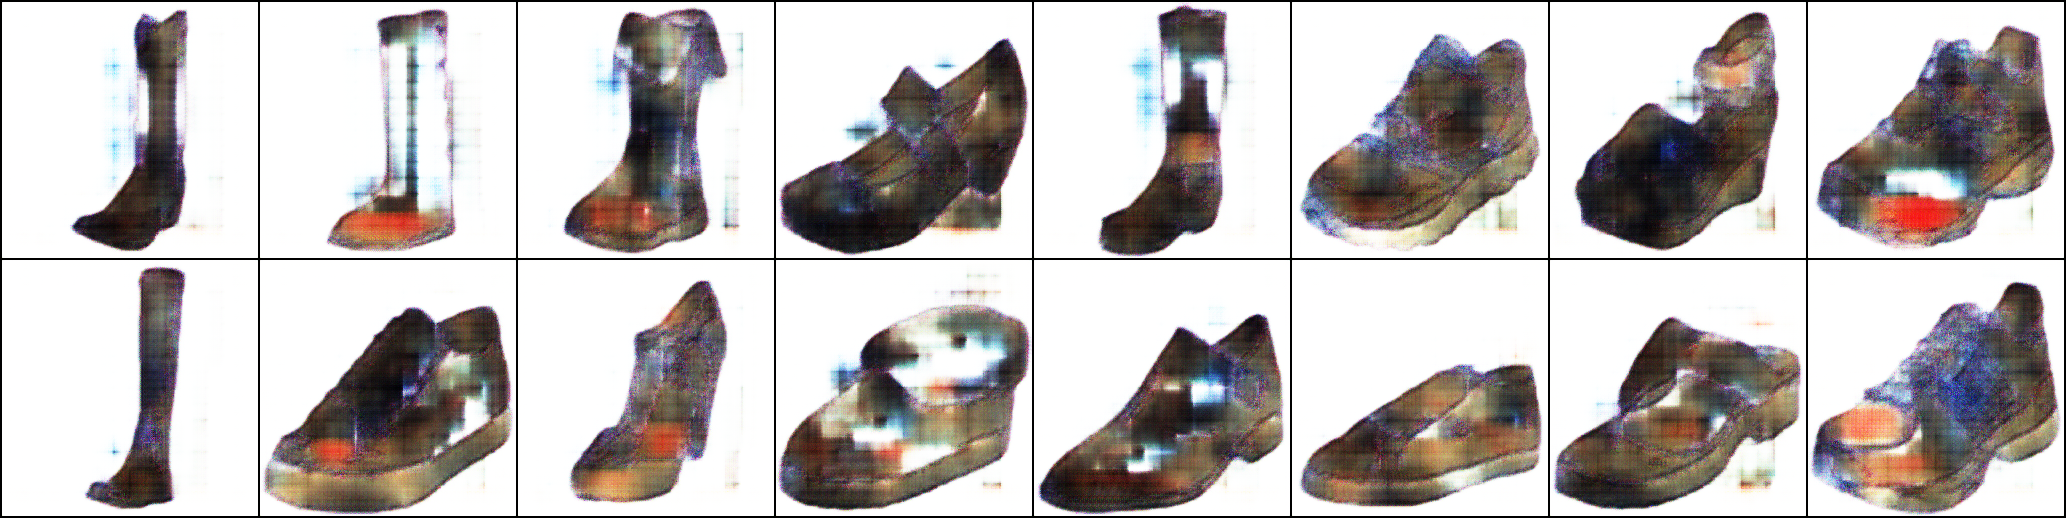

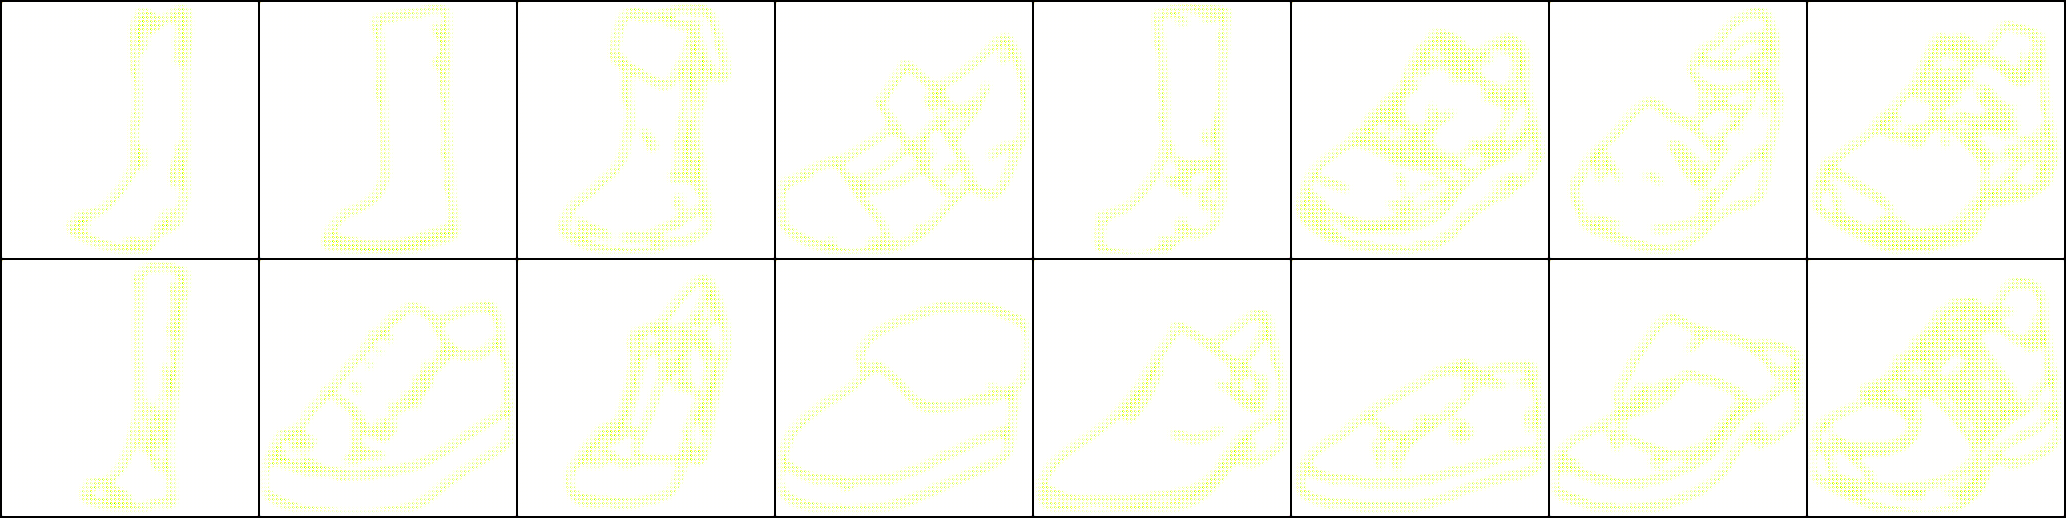

In [2]:
from PIL import Image
from IPython.display import display

display(Image.open("/content/results/pix2pix_epoch_2.png"))
display(Image.open("/content/results/cnn_epoch_2.png"))